In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("u.data", sep="\t", header=None)
data.columns = ["user_id", "movie_id", "rating", "timestamp"]

In [3]:
movies = pd.read_csv("u.item", sep="|", encoding="latin-1", header=None)
movies = movies[[0,1]]
movies.columns = ["movie_id", "movie_name"]

movie_dict = dict(zip(movies.movie_id, movies.movie_name))

In [4]:
item_user_matrix = data.pivot_table(index="movie_id", columns="user_id", values="rating")
item_user_matrix = item_user_matrix.fillna(0)

In [5]:
item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix.index,
                                 columns=item_user_matrix.index)

In [6]:
def get_similar_items(movie_id, n=5):
    similar_items = item_similarity_df[movie_id].sort_values(ascending=False)
    return similar_items.iloc[1:n+1]

In [ ]:
def recommend_items(user_id, n=5):
    user_ratings = data[data['user_id'] == user_id]
    
    high_rated = user_ratings[user_ratings['rating'] >= 4]['movie_id']
    
    scores = {}
    
    for movie in high_rated:
        similar_movies = get_similar_items(movie, n=10)
        
        for sim_movie, score in similar_movies.items():
            if sim_movie not in high_rated.values:
                scores[sim_movie] = scores.get(sim_movie, 0) + score
    
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_scores[:n]  

In [8]:
print(recommend_items(1))

[(69, 12.989766331074376), (423, 9.639853904726015), (117, 7.55882494760579), (405, 6.7402156457742395), (385, 5.99813505147096)]


In [14]:
def predict_rating(user_id, movie_id):
    user_ratings = item_user_matrix[user_id]

    rated_movies = user_ratings[user_ratings > 0]

    similarities = item_similarity_df[movie_id][rated_movies.index]

    if similarities.sum() == 0:
        return 0

    prediction = np.dot(similarities, rated_movies) / similarities.sum()

    return prediction

In [16]:
y_true = []
y_pred = []

for user in data['user_id'].unique():
    user_data = data[data['user_id'] == user]
    
    for _, row in user_data.iterrows():
        movie = row['movie_id']
        
        pred = predict_rating(user, movie)
        
        y_true.append(row['rating'])
        y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

RMSE: 0.9744437536364795


In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
data=train_data  
def precision_at_k(user_id, k=5):
    test_user = test_data[test_data['user_id'] == user_id]
    relevant = test_user[test_user['rating'] >= 4]['movie_id'].values
    
    if len(relevant) == 0:
        return 0     
    recommended = [m[0] for m in recommend_items(user_id, k)]    
    hits = len(set(recommended) & set(relevant))    
    return hits / k
print(precision_at_k(1))

0.8


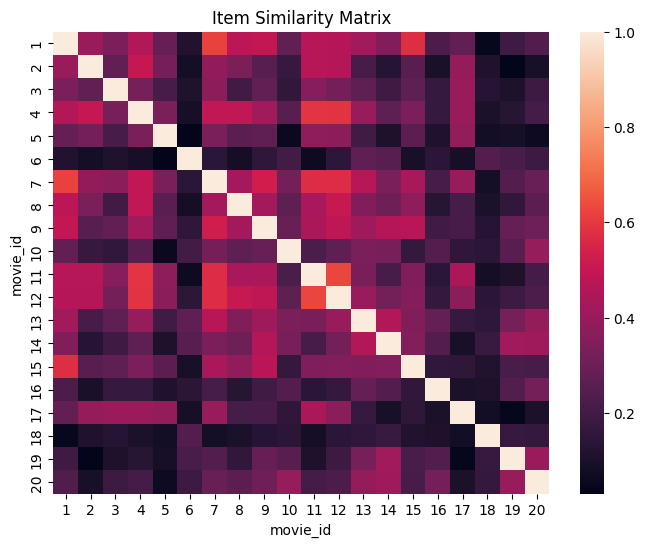

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Matrix")
plt.show()

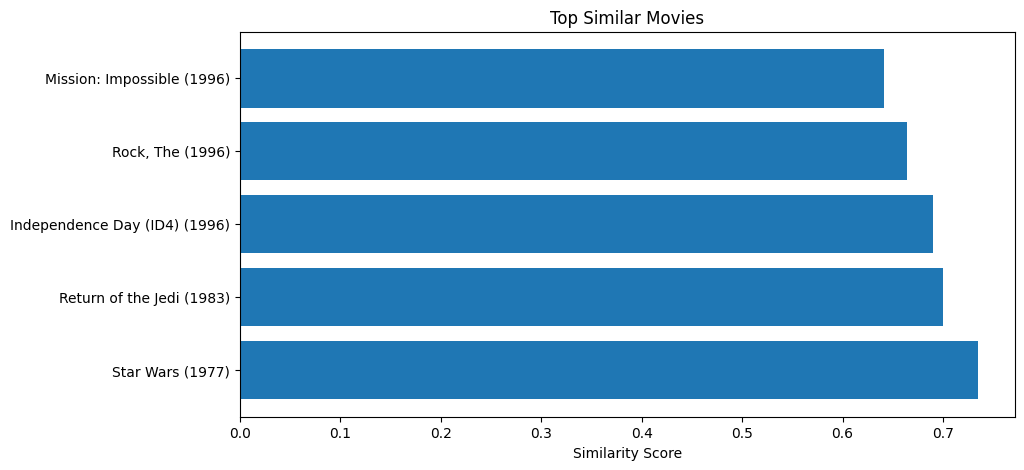

In [12]:
movie_id = 1
similar = get_similar_items(movie_id)

names = [movie_dict.get(mid) for mid in similar.index]

plt.figure(figsize=(10,5))
plt.barh(names, similar.values)

plt.title("Top Similar Movies")
plt.xlabel("Similarity Score")
plt.show()

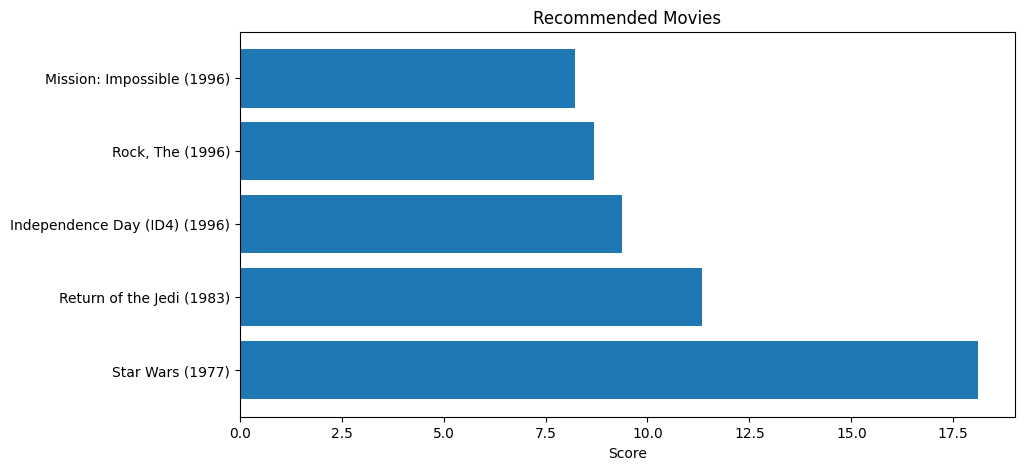

In [13]:
rec = recommend_items(1)

names = [r[0] for r in rec]
scores = [r[1] for r in rec]
names = [movie_dict.get(mid) for mid in similar.index]
plt.figure(figsize=(10,5))
plt.barh(names, scores)

plt.title("Recommended Movies")
plt.xlabel("Score")
plt.show()